## Convection-Diffusion with Spatially Varying Heat Transfer Coefficient -- PIDeepONet

PDE:
$$-k\nabla^2 T(x,y) + h(x,y)\,T(x,y) = 0, \quad (x,y)\in\Omega=[0,1]^2$$

where $k=1$ (normalised constant thermal conductivity) and $h(x,y)>0$ is a spatially
varying convection coefficient modelling non-uniform coolant heat transfer.

### (1.1) Boundary conditions

| Wall | Condition |
|---|---|
| Left $x=0$ | $T = 1$ (hot-gas-side wall) |
| Right $x=1$ | $T = 0$ (coolant side) |
| Top/bottom $y=0,1$ | $\partial T/\partial n = 0$ (symmetry) |

### (1.2) Convection coefficient parameterisation

$$h(x,y) = \exp\!\bigl(\alpha\sin(\pi x) + \beta\cos(\pi y)\bigr),
\quad \alpha,\beta\sim\mathrm{Uniform}(-1,1)$$

Always positive, spatially smooth, physically meaningful (models non-uniform
coolant channel geometry in regenerative cooling applications).

### (1.3) Neural operator learning problem

$$\mathcal{G}:\; h(x,y) \;\longrightarrow\; T(x,y)$$

**Mollifier** (identical to mass diffusion -- exact BC enforcement):
$$T = u_{\mathrm{NN}}(x,y)\cdot x(1-x)\cdot\sin(\pi y) + (1-x)$$

**PDE residual** via two FDM passes (mirrors PIDeepONet_DarcyFlowPWC_fdm exactly):
$$\mathcal{R} = -\nabla^2 T + h\,T = 0$$

The $h\,T$ reaction term provides natural amplitude damping -- unlike pure Poisson,
the solution is always $T\in[0,1]$ and well-conditioned for pure PI training.

## (2) The Physics-Informed DeepONet

In [48]:
import sys
sys.path.append('../..')
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
random_seed = 1234
setup_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda:0'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print('Using device:', device)

dtype = torch.float32
tag   = 'convdiff'
res   = 29

######################################
# Load dataset
######################################
data_train = h5py.File('../../Problems/convDiff_2d/convdiff_train.mat', 'r')
data_test  = h5py.File('../../Problems/convDiff_2d/convdiff_test.mat',  'r')
print('train keys:', list(data_train.keys()))
print('test  keys:', list(data_test.keys()))

from Utils.utils import *
n_train, n_test = 1000, 200

def get_data(data, ndata, dtype, n0=0):
    # Align physics arrays to (Batch, Ny, Nx)
    a_aligned = np.array(data['coeff'][..., n0:n0+ndata]).transpose(2, 1, 0)
    u_aligned = np.array(data['sol_fdm'][..., n0:n0+ndata]).transpose(2, 1, 0)
    
    a = np2tensor(a_aligned, dtype)
    u = np2tensor(u_aligned, dtype)
    
    # Extract grids without .T
    X = np.array(data['X']) 
    Y = np.array(data['Y'])
    
    # Correctly pair (X, Y) into shape (N, 2)
    grid_points = np.column_stack((X.ravel(), Y.ravel()))
    gridx = np2tensor(grid_points, dtype)
    x = gridx.repeat((ndata, 1, 1))
    
    # Flatten spatial dimensions
    a = a.reshape(ndata, -1, 1)
    u = u.reshape(ndata, -1, 1)
    
    return a, u, x, gridx

a_train, u_train, x_train, grid_train = get_data(data_train, n_train, dtype)
a_test,  u_test,  x_test,  grid_test  = get_data(data_test,  n_test,  dtype)
print('a_train:', a_train.shape, '  u_train:', u_train.shape)
print('x_train:', x_train.shape, '  grid_train:', grid_train.shape)

# Quick data sanity check
print('h range (a_test):', a_test.min().item(), a_test.max().item(),
      '  expect ~[0.14, 7.39]')
print('T range (u_test):', u_test.min().item(), u_test.max().item(),
      '  expect ~[0, 1]')

######################################
# Structured mesh for FDM residual
######################################
from Utils.GenPoints import Point2D
pointGen = Point2D(x_lb=[0., 0.], x_ub=[1., 1.], dataType=dtype,
                   random_seed=random_seed)
N_mesh = 29
x_mesh = pointGen.inner_point(N_mesh, method='mesh')  # (N_mesh^2, 2)
print('x_mesh shape:', x_mesh.shape)

Using device: cuda:0
train keys: ['X', 'Y', 'alpha', 'beta', 'coeff', 'sol_fdm']
test  keys: ['X', 'Y', 'alpha', 'beta', 'coeff', 'sol_fdm']
a_train: torch.Size([1000, 841, 1])   u_train: torch.Size([1000, 841, 1])
x_train: torch.Size([1000, 841, 2])   grid_train: torch.Size([841, 2])
h range (a_test): 0.14348310232162476 6.730010032653809   expect ~[0.14, 7.39]
T range (u_test): 0.0 1.0   expect ~[0, 1]
x_mesh shape: torch.Size([841, 2])


### (3.2) Define the loss class and train the model

In [49]:
from Utils.Grad import *
import torch.nn as nn
from torch.autograd import Variable

########################################
class fun_h(object):
    # Nearest-grid-point lookup of h(x,y) at mesh points.
    # Called with x_mesh (2D, N_mesh^2 x 2) like the Darcy fun_a.

    def __init__(self, res):
        self.res   = res
        self.delta = 1.0 / (res - 1)

    def __call__(self, x, a):
        a     = a.squeeze(-1)                         # (n_batch, res^2)
        x_loc = torch.floor(x[..., 0] / self.delta + 0.5).int().clamp(0, self.res-1)
        y_loc = torch.floor(x[..., 1] / self.delta + 0.5).int().clamp(0, self.res-1)
        loc   = y_loc * self.res + x_loc
        img   = a[torch.arange(a.size(0)).unsqueeze(1), loc]
        return img.unsqueeze(-1)                       # (n_batch, N_pts, 1)

########################################
class mollifier(object):
    # T = u_NN * x*(1-x) + (1-x)
    # T(0,y)=1, T(1,y)=0. 
    # y-boundaries are FREE (Neumann enforced via loss penalty)

    def __call__(self, u, x):
        xx = x[..., 0:1]
        # yy no longer restricts the network
        return u * xx * (1.0 - xx) + (1.0 - xx)
        
################################
class LossClass(object):

    def __init__(self, solver):
        self.solver    = solver
        self.dtype     = solver.dtype
        self.device    = solver.device
        self.fun_h     = fun_h(res=res)
        self.model_u   = solver.model_dict['u']
        self.mollifier = mollifier()
        self.deltax    = 1.0 / (N_mesh - 1)
        self.deltay    = 1.0 / (N_mesh - 1)

    def Loss_pde(self, a_batch, w_pde):
        # PDE residual: -Lap(T) + h*T = 0
        # dim convention: dim1=y (rows), dim2=x (cols)
        n_batch = a_batch.shape[0]
        if w_pde > 0.0:
            h = self.fun_h(x_mesh, a_batch)   # (n_batch, N_mesh^2, 1)
            x = Variable(
                x_mesh.repeat(n_batch, 1, 1).to(self.device),
                requires_grad=False
            )

            # Network prediction + mollifier
            T = self.model_u(x, a_batch)
            T = self.mollifier(T, x).reshape(-1, N_mesh, N_mesh, 1)
            h = h.reshape(-1, N_mesh, N_mesh, 1)

            # Step 1: first derivatives of T
            dTdx, dTdy = FDM_2d(T, self.deltax, self.deltay)

            # Step 2: second derivatives
            d2Tdx2, _  = FDM_2d(dTdx, self.deltax, self.deltay)
            _, d2Tdy2  = FDM_2d(dTdy, self.deltax, self.deltay)
            lap_T = d2Tdx2 + d2Tdy2   # (n_batch, N_mesh-4, N_mesh-4, 1)

            # Step 3: reaction term h*T at doubly-interior points
            h_col = h[:, 2:-2, 2:-2, :]   
            T_col = T[:, 2:-2, 2:-2, :]   

            # Base PDE Residual: -Lap(T) + h*T = 0
            left  = (-lap_T + h_col * T_col).reshape(n_batch, -1)
            right = torch.zeros_like(left)
            loss_res = self.solver.getLoss(left, right)
            
            # --- NEW: Soft Neumann Boundary Conditions via FDM ---
            # dT/dy = 0 at y=0 (top edge, index 0) and y=1 (bottom edge, index -1)
            # Using forward difference for y=0 and backward difference for y=1
            dTdy_y0 = (T[:, 1, :, :] - T[:, 0, :, :]) / self.deltay
            dTdy_y1 = (T[:, -1, :, :] - T[:, -2, :, :]) / self.deltay
            
            loss_bc = self.solver.getLoss(dTdy_y0, torch.zeros_like(dTdy_y0)) + \
                      self.solver.getLoss(dTdy_y1, torch.zeros_like(dTdy_y1))
            
            # Lambda multiplier for boundary penalty. 
            # 5.0 is a good starting weight to ensure it respects the boundaries.
            lambda_bc = 5.0 
            
            return loss_res + lambda_bc * loss_bc
            
        return torch.tensor(0.0)

    def Loss_data(self, x, a, u, w_data):
        if w_data > 0.0:
            u_pred = self.model_u(x, a)
            u_pred = self.mollifier(u_pred, x)
            return self.solver.getLoss(u_pred, u)
        return torch.tensor(0.0)
    
    def Error(self, x, a, u):
        u_pred = self.model_u(x, a)
        u_pred = self.mollifier(u_pred, x)
        return self.solver.getError(u_pred, u)

######################################
# Model setup
######################################
from Solvers.PIDeepONet import PIDeepONet
solver  = PIDeepONet.Solver(device=device, dtype=dtype)
netType = 'DeepONetBatch'

from Networks.CNNet import CNNet2d

class BranchNet(nn.Module):
    def __init__(self, conv_arch, fc_arch, nx_size, ny_size, dtype=None):
        super().__init__()
        self.nx_size = nx_size
        self.ny_size = ny_size
        self.conv = CNNet2d(
            conv_arch=conv_arch, fc_arch=fc_arch,
            activation_conv='SiLU', activation_fc='SiLU',
            kernel_size=(3, 3), stride=2, dtype=dtype
        )
    def forward(self, x):
        x = x.reshape(-1, self.ny_size, self.nx_size).unsqueeze(1)
        return self.conv(x)

conv_arch = [1, 64, 64, 64]
fc_arch   = [64*2*2, 128, 128, 128]
branchNet = BranchNet(conv_arch, fc_arch, nx_size=res, ny_size=res, dtype=dtype)

layers_branch, activation_branch = [branchNet, fc_arch[-1]], 'SiLU'
layers_trunk,  activation_trunk  = [2, 128, 128, 128, 128], 'ReLU'
model_u = solver.getModel(
    layers_branch, layers_trunk, activation_branch, activation_trunk,
    multi_ouput_strategy=None, num_output=1, netType=netType
)
n_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'{n_params:,} trainable parameters.')

190,337 trainable parameters.


### (2.3) Training and prediction

#### (2.3.1) Train the model

In [52]:
model_dict = {'u': model_u}
solver.train_setup(model_dict, lr=1e-3, optimizer='Adam',
                   scheduler_type='StepLR', gamma=0.6, step_size=200)
solver.train(LossClass, a_train, u_train, x_train, a_test, u_test, x_test,
             w_data=0., w_pde=1., batch_size=50, epochs=2500, epoch_show=100,
             **{'save_path': f'saved_models/PI{netType}_{tag}/'})

  4%|███▏                                                                           | 100/2500 [00:24<09:27,  4.23it/s]

Epoch:100 Time:24.3720, loss:8.0664, loss_pde:8.0664, loss_data:0.0000
                l2_test:0.0255, lr:0.001


  8%|██████▎                                                                        | 200/2500 [00:47<09:01,  4.25it/s]

Epoch:200 Time:47.7530, loss:8.0380, loss_pde:8.0380, loss_data:0.0000
                l2_test:0.0239, lr:0.0006


 12%|█████████▍                                                                     | 300/2500 [01:10<08:31,  4.30it/s]

...

Epoch:2300 Time:540.0570, loss:7.4609, loss_pde:7.4609, loss_data:0.0000
                l2_test:0.0187, lr:3.6279705599999985e-06


 96%|██████████████████████████████████████████████████████████████████████████▉   | 2400/2500 [09:23<00:23,  4.30it/s]

Epoch:2400 Time:563.4302, loss:7.4587, loss_pde:7.4587, loss_data:0.0000
                l2_test:0.0187, lr:2.176782335999999e-06


100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [09:46<00:00,  4.26it/s]

Epoch:2500 Time:586.8892, loss:7.4573, loss_pde:7.4573, loss_data:0.0000
                l2_test:0.0186, lr:2.176782335999999e-06
The total training time is 586.9262


### (3.3) Load saved model and make prediction

Test L2 error (avg): tensor(0.0162)


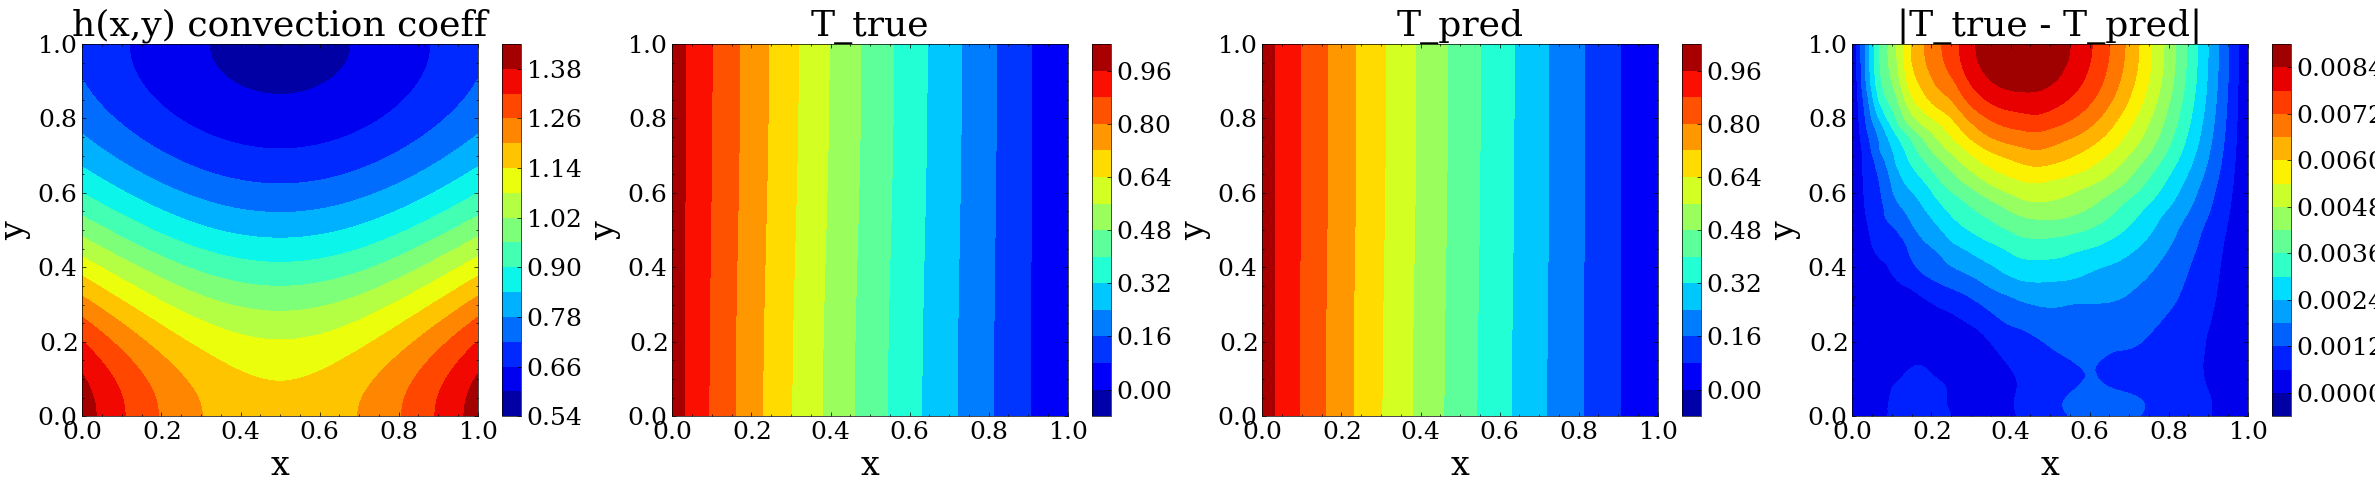

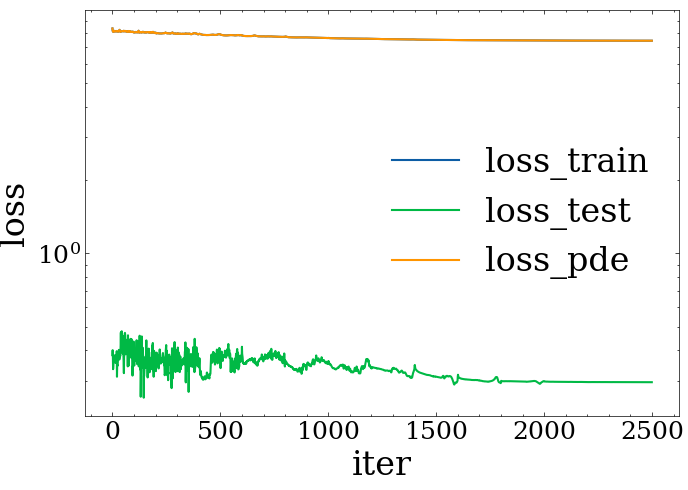

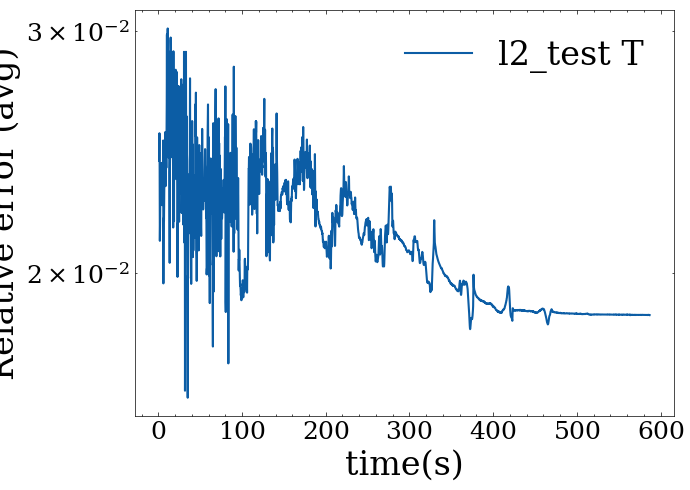

In [53]:
#######################################
# Load the trained model
#######################################
from Solvers.PIDeepONet import PIDeepONet
from torch.autograd import Variable

solver = PIDeepONet.Solver(device=device, dtype=dtype)
model_trained = solver.loadModel(
    path=f'saved_models/PI{netType}_{tag}/',
    name='model_pideeponet_besterror'
)

#########################################
# Predict on test set
#########################################
x_var = Variable(x_test.to(device), requires_grad=False)
a_var = a_test.to(device)
with torch.no_grad():
    u_pred = model_trained['u'](x_var, a_var)
    u_pred = mollifier()(u_pred, x_var).detach().cpu()

print('Test L2 error (avg):', solver.getError(u_pred, u_test))

#########################################
# Visualise one sample
#########################################
inx = 0
from Utils.PlotFigure import Plot
Plot.show_2d_list(
    [grid_test] * 4,
    [a_test[inx], u_test[inx], u_pred[inx],
     torch.abs(u_test[inx] - u_pred[inx])],
    ['h(x,y) convection coeff', 'T_true', 'T_pred', '|T_true - T_pred|'],
    lb=0., ub=1.
)

#########################################
# Loss and error curves
#########################################
loss_saved = solver.loadLoss(
    path=f'saved_models/PI{netType}_{tag}/', name='loss_pideeponet'
)
Plot.show_loss(
    [loss_saved['loss_train'], loss_saved['loss_test'], loss_saved['loss_pde']],
    ['loss_train', 'loss_test', 'loss_pde']
)
Plot.show_error([loss_saved['time']], [loss_saved['error']], ['l2_test T'])

In [1]:
# outputs high res figures for LaTeX document

import os, matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np, torch

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

fig_dir = './figures'
os.makedirs(fig_dir, exist_ok=True)

# ── Helpers ────────────────────────────────────────────────────────────────────
def tri_contourf(ax, xy, field, **kw):
    return ax.tricontourf(xy[:,0], xy[:,1], field, levels=50, **kw)

XY = grid_test.numpy()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 1 -- Training loss convergence (semi-log)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.5))
iters = np.arange(1, len(loss_saved['loss_pde']) + 1)
ax.semilogy(iters, loss_saved['loss_pde'],   color='tab:orange', lw=1.2, label='PDE loss')
ax.semilogy(iters, loss_saved['loss_train'],  color='tab:blue',   lw=1.2, label='Train loss', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Convergence')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.4)
fig.tight_layout()
fig.savefig(f'{fig_dir}/convdiff_loss.pdf')
plt.close(fig)
print('Saved: convdiff_loss.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# FIG 2 -- Test L2 error vs wall-clock time
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(loss_saved['time'], loss_saved['error'], color='tab:blue', lw=1.2)
ax.set_xlabel('Wall-clock time (s)')
ax.set_ylabel(r'Relative $L^2$ error (avg)')
ax.set_title(r'Test Error vs Training Time')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid(True, ls='--', alpha=0.4)
ax.legend([r'$L^2$ test error T'])
fig.tight_layout()
fig.savefig(f'{fig_dir}/convdiff_error.pdf')
plt.close(fig)
print('Saved: convdiff_error.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# FIG 3 -- Field comparison for a representative test sample
# ─────────────────────────────────────────────────────────────────────────────
inx = 0
h_field   = a_test[inx, :, 0].numpy()
T_true    = u_test[inx, :, 0].numpy()
T_pred_np = u_pred[inx, :, 0].numpy()
T_err     = np.abs(T_true - T_pred_np)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))

panels = [
    (h_field,   r'$h(x,y)$ [convection coeff]', 'plasma'),
    (T_true,    r'$T_\mathrm{true}$ (FDM)',     'hot_r'),
    (T_pred_np, r'$T_\mathrm{pred}$ (PIDeepONet)', 'hot_r'),
    (T_err,     r'$|T_\mathrm{true} - T_\mathrm{pred}|$', 'Reds'),
]
for ax, (field, title, cmap) in zip(axes, panels):
    sc = tri_contourf(ax, XY, field, cmap=cmap)
    cb = fig.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
    cb.ax.tick_params(labelsize=9)
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')

fig.tight_layout()
fig.savefig(f'{fig_dir}/convdiff_fields.pdf')
plt.close(fig)
print('Saved: convdiff_fields.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# FIG 4 -- h(x,y) input field alone (for physics section of paper)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.8, 3.2))
sc = tri_contourf(ax, XY, h_field, cmap='plasma')
fig.colorbar(sc, ax=ax, shrink=0.9, pad=0.02, label=r'$h(x,y)$')
ax.set_title(r'Convection coefficient $h(x,y)$' + '\n' +
             r'$h = e^{\alpha\sin(\pi x)+\beta\cos(\pi y)}$')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$'); ax.set_aspect('equal')
fig.tight_layout()
fig.savefig(f'{fig_dir}/convdiff_h_input.pdf')
plt.close(fig)
print('Saved: convdiff_h_input.pdf')

print(f'\nAll figures saved to {os.path.abspath(fig_dir)}/')
print('Copy the figures/ folder into your Overleaf project.')

NameError: name 'grid_test' is not defined